# Spatial Niches in mIF Data

## Prepare Data

In [1]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#f = "lung-cohort-tabular-data-small/tsv/cells_properties/LUNG-NSCLC2-0558-FIXT-01-IF1-01_#_cells_properties_#_f9e776cbf3f124bd9a0d3af7ab4423ba.tsv.gz"


# ── Constants ────────────────────────────────────────────────────────────────
CELL_TYPES = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC", "Neutrophil", "other"
]
N_TYPES = len(CELL_TYPES)
CT_TO_IDX = {ct: i for i, ct in enumerate(CELL_TYPES)}

# Fixed colour palette for cell types
CT_PALETTE = dict(zip(CELL_TYPES,
    ["#e6194b","#f58231","#3cb44b","#4363d8",
     "#911eb4","#42d4f4","#f032e6","#bfef45","#aaaaaa"]))

# Fixed colour palette for spatial niches (up to 8)
NICHE_PALETTE = ["#e41a1c","#377eb8","#4daf4a","#984ea3",
                 "#ff7f00","#a65628","#f781bf","#999999"]

DATA_DIR = "unzipped/tsv/cells_properties/"
SAMPLE_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*_celltype.tsv")))
print(f"Found {len(SAMPLE_FILES)} sample files")

Found 15 sample files


## Paart 1 - Immune-Cell Infiltration Profiles

In [2]:
#results for each patient
results = []
patient_dfs = {}


for patient_file in SAMPLE_FILES:
    #patient info
    patient_id = Path(patient_file).name.split("-")[2]    
    df = pd.read_csv(patient_file, sep="\t")

    #matrix of all cell coords
    coords = df[["nucleus.x", "nucleus.y"]].values

    #splitting
    is_tumor = df["tissue.type"] == "tumor"
    is_stroma = df["tissue.type"] == "stroma"

    #cell cords of each type
    tumor_coords = coords[is_tumor]
    stroma_coords = coords[is_stroma]

    #KDTrees making
    tumor_tree = cKDTree(tumor_coords)
    stroma_tree = cKDTree(stroma_coords)

    #distances to the nearest cell opposite type (for all tumor cells, not only roi)
    tumor_dist, _ = stroma_tree.query(tumor_coords, k=1)
    stroma_dist, _ = tumor_tree.query(stroma_coords, k=1)


    df["signed_border_dist"] = np.nan

    # tumour side = positive
    df.loc[is_tumor, "signed_border_dist"] = tumor_dist

    # stroma side = negative
    df.loc[is_stroma, "signed_border_dist"] = -stroma_dist

    
    #saving the distance data (as border_dist)
    df["border_dist"] = np.nan
    df.loc[is_tumor, "border_dist"] = tumor_dist
    df.loc[is_stroma, "border_dist"] = stroma_dist

    # Some files contain generic ROI columns only.
    # Based on inspection, ROI.1 corresponds to tumour ROI in these samples.
    #all T cells that are inside the tumour ROI 
    if "in.ROI.tumor_tissue" in df.columns:
        roi_col = "in.ROI.tumor_tissue"
    else:
        roi_col = "in.ROI.1"

    T_roi = df[
        (df["cell.type"] == "Tcell") &
        (df[roi_col])
    ]

    #for D1.2 plot
    roi_df = df[df[roi_col]]

    #using median as infiltration score (how far from the border are the cells)
    score = T_roi["border_dist"].median()

    patient_dfs[patient_id] = df


    #saving results
    results.append({
        "patient": patient_id,
        "roi_used": roi_col,
        "n_T_cells": len(T_roi),
        "infiltration_score": score
    })


scores = pd.DataFrame(results)

#ranking the patients
ranked = scores.sort_values(
    "infiltration_score",
    ascending=False
).reset_index(drop=True)


ranked.index = ranked.index + 1
ranked.to_csv("outputs/D1_ranked.csv")
ranked

,patient,roi_used,n_T_cells,infiltration_score
1,0699,in.ROI.tumor_tissue,159587,54.873035
2,0587,in.ROI.tumor_tissue,217089,43.126094
3,0664,in.ROI.tumor_tissue,44801,37.813225
4,0558,in.ROI.tumor_tissue,272987,37.051990
5,0613,in.ROI.tumor_tissue,180041,30.793668
6,0696,in.ROI.1,49044,30.346334
7,0657,in.ROI.tumor_tissue,47603,29.689224
8,0721,in.ROI.1,10901,27.804496
9,0591,in.ROI.tumor_tissue,77447,27.668394
10,0565,in.ROI.tumor_tissue,92434,27.136414


### Border-distance distributions across different cell types

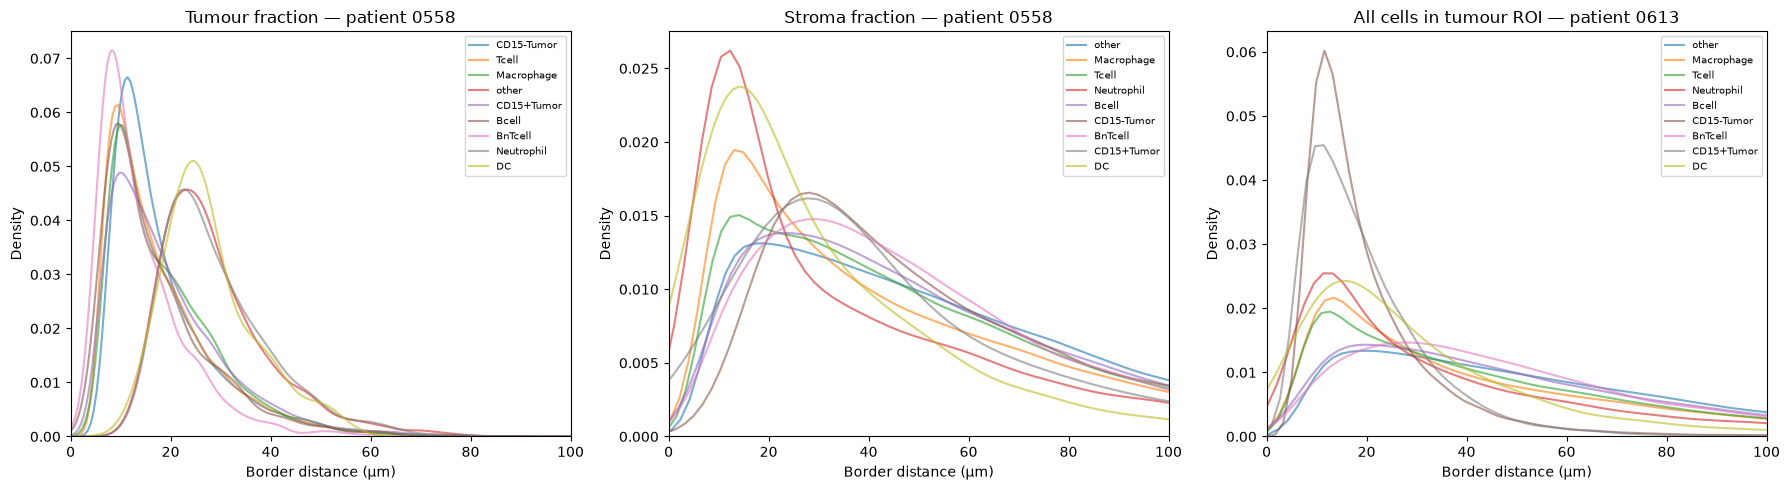

In [3]:

#1 patient
df_p = patient_dfs["0558"]

#chosing columns
roi_col = (
    "in.ROI.tumor_tissue"
    if "in.ROI.tumor_tissue" in df_p.columns
    else "in.ROI.1"
)

#all cells in ROI
roi_df = df_p[df_p[roi_col]]


tumor_df = roi_df[roi_df["tissue.type"] == "tumor"]
stroma_df = roi_df[roi_df["tissue.type"] == "stroma"]


fig, axes = plt.subplots(1, 3, figsize=(18,5))


#tumor cell fractions
for ct in tumor_df["cell.type"].unique():

    data = tumor_df.loc[
        tumor_df["cell.type"] == ct,
        "border_dist"
    ]

    if len(data) > 10:
        sns.kdeplot(
            data,
            label=ct,
            alpha=0.6,
            ax=axes[0]
        )

axes[0].set_title("Tumour fraction — patient 0558")
axes[0].set_xlabel("Border distance (µm)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0,100)
axes[0].legend(fontsize=7)



#stroma fraction
for ct in stroma_df["cell.type"].unique():

    data = stroma_df.loc[
        stroma_df["cell.type"] == ct,
        "border_dist"
    ]

    if len(data) > 10:
        sns.kdeplot(
            data,
            label=ct,
            alpha=0.6,
            ax=axes[1]
        )

axes[1].set_title("Stroma fraction — patient 0558")
axes[1].set_xlabel("Border distance (µm)")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0,100)
axes[1].legend(fontsize=7)



#both fractions
for ct in roi_df["cell.type"].unique():

    data = roi_df.loc[
        roi_df["cell.type"] == ct,
        "border_dist"
    ]

    if len(data) > 10:
        sns.kdeplot(
            data,
            label=ct,
            alpha=0.6,
            ax=axes[2]
        )

axes[2].set_title("All cells in tumour ROI — patient 0613")
axes[2].set_xlabel("Border distance (µm)")
axes[2].set_ylabel("Density")
axes[2].set_xlim(0,100)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(
    "outputs/border_distance_distribution_patient_0558.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


T cells are concentrated near the border.
###  T-cell infiltration profiles plot

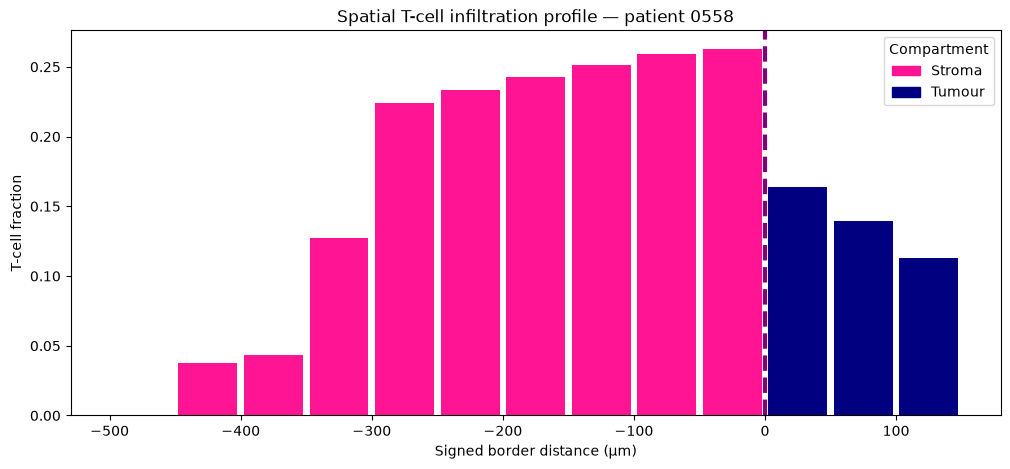

In [4]:
#one patient
df_p = patient_dfs["0558"]


roi_df = df_p.copy()

bin_edges = np.arange(
    np.floor(roi_df["signed_border_dist"].min()/50)*50,
    np.ceil(roi_df["signed_border_dist"].max()/50)*50 + 50,
    50
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


roi_df["distance_bin"] = np.digitize(
    roi_df["signed_border_dist"],
    bin_edges
) - 1

T_fraction = []

for b in range(len(bin_centers)):

    cells_bin = roi_df[roi_df["distance_bin"] == b]

    if len(cells_bin) == 0:
        T_fraction.append(np.nan)

    else:
        T_fraction.append(
            (cells_bin["cell.type"] == "Tcell").sum() / len(cells_bin))

#defining different colors fro tumor and stroma
colors = ["deeppink" if x < 0 else "navy" for x in bin_centers]

#plotting
plt.figure(figsize=(12,5))

plt.bar(
    bin_centers,
    T_fraction,
    width=45,
    color=colors
)

#border
plt.axvline(
    0,
    linestyle="--",
    lw=3,
    color='purple'
)

#sign shows the side
plt.xlabel("Signed border distance (µm)")
plt.ylabel("T-cell fraction")
plt.title("Spatial T-cell infiltration profile — patient 0558")


#legend
stroma_patch = mpatches.Patch(color="deeppink", label="Stroma")
tumour_patch = mpatches.Patch(color="navy",label="Tumour")


plt.legend(handles=[stroma_patch, tumour_patch],title="Compartment")

plt.savefig(
    "outputs/infiltration_profile_patient_0558.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Immune cell infiltration across all patients

In [5]:
#all patients
ranked

,patient,roi_used,n_T_cells,infiltration_score
1,0699,in.ROI.tumor_tissue,159587,54.873035
2,0587,in.ROI.tumor_tissue,217089,43.126094
3,0664,in.ROI.tumor_tissue,44801,37.813225
4,0558,in.ROI.tumor_tissue,272987,37.051990
5,0613,in.ROI.tumor_tissue,180041,30.793668
6,0696,in.ROI.1,49044,30.346334
7,0657,in.ROI.tumor_tissue,47603,29.689224
8,0721,in.ROI.1,10901,27.804496
9,0591,in.ROI.tumor_tissue,77447,27.668394
10,0565,in.ROI.tumor_tissue,92434,27.136414


In [6]:
high = ranked.head(3)[["patient", "n_T_cells", "infiltration_score"]]
low = ranked.tail(3)[["patient", "n_T_cells", "infiltration_score"]]

print("HIGH infiltration")
print(high[["patient","infiltration_score","n_T_cells"]])


print("\nLOW infiltration")
print(low[["patient","infiltration_score","n_T_cells"]])


HIGH infiltration
  patient  infiltration_score  n_T_cells
1    0699           54.873035     159587
2    0587           43.126094     217089
3    0664           37.813225      44801

LOW infiltration
   patient  infiltration_score  n_T_cells
13    0612           23.479779      31693
14    0616           20.934660      92018
15    0695           16.888458      26858


Patients were classified based on median T-cell border distance into infiltrated, intermediate, and excluded-like groups. 

High-infiltration patients showed larger T-cell distances from the tumour–stroma boundary, suggesting deeper tumour penetration and an immune-infiltrated phenotype. 

Intermediate patients displayed heterogeneous spatial patterns, where some T cells entered tumour regions but immune penetration is incomplete.

Low-infiltration patients showed T-cell localisation closer to the boundary, consistent with  partial immune exclusion, where immune cells accumulate near the edge rather than efficiently entering the tumour core.

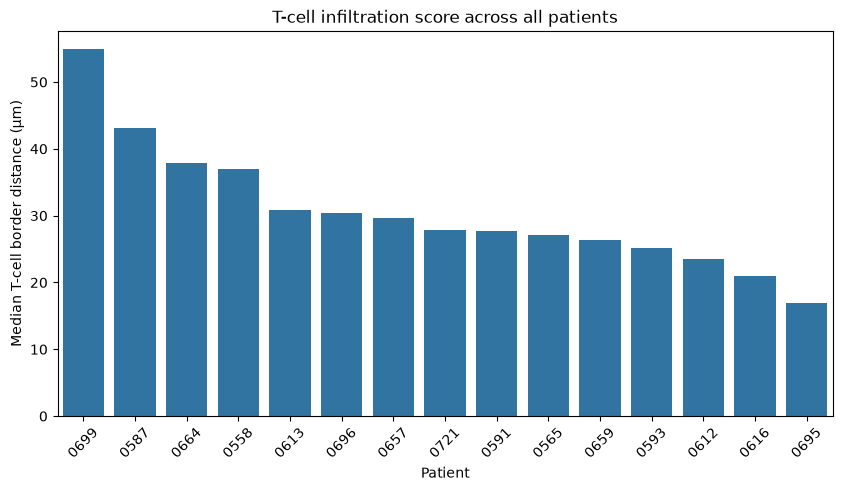

In [7]:
#an additional plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=ranked,
    x="patient",
    y="infiltration_score"
)

plt.xticks(rotation=45)

plt.ylabel("Median T-cell border distance (µm)")

plt.xlabel("Patient")

plt.title("T-cell infiltration score across all patients")
plt.savefig(
    "outputs/infiltration_across_all_patients.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Part 2 - Moran’s I Spatial Clustering

In [8]:

#first patient
df = pd.read_csv(SAMPLE_FILES[0], sep="\t")

#sample 50000
df = df.sample(
    50000,
    random_state=42
).reset_index(drop=True)

#saving cell positions
coords = df[["nucleus.x","nucleus.y"]].values
#KDtree
tree = cKDTree(coords)

#10 closest neighbours (KNN)
K = 10
distances, neighbors = tree.query(coords, k=K+1)
#a cell is not its own neighbour (final data for morana)
neighbors = neighbors[:,1:]


print("amount of cells:", neighbors.shape[0])
print("amount of neighbours:", neighbors.shape[1])



#the implementation of Moran's I
def morans_I(x, neighbors):

    N = len(x)

    x_centered = x - x.mean()

    numerator = np.sum(
        x_centered[:, None] *
        x_centered[neighbors]
    )

    denominator = np.sum(
        x_centered ** 2
    )

    W = neighbors.size

    I = (
        N / W *
        numerator /
        denominator
    )

    return I

amount of cells: 50000
amount of neighbours: 10


### Validation - Sanity checks

In [9]:
#cluster
x_cluster = (
    coords[:,0] < np.percentile(coords[:,0], 20)
).astype(int)

moran_clust = morans_I(x_cluster,neighbors)

#random
x_random = np.random.permutation(x_cluster)
moran_rand = morans_I( x_random, neighbors)


print("cluster:", moran_clust)
print("random:", moran_rand )


cluster: 0.9890825000000001
random: -0.0013349999999999617


### Cell-type results

In [10]:
#for 9 cell types on the 1st patient, checking potential clusters

results = []

#for each cell type
for ct in CELL_TYPES:

    x = (df["cell.type"] == ct).astype(int).values

    #using the knn
    I = morans_I(x, neighbors)


    results.append({
        "cell.type":ct,
        "morans_I":I
    })

moran_df = pd.DataFrame(results)

moran_df

,cell.type,morans_I
0,CD15-Tumor,0.122165
1,CD15+Tumor,0.020565
2,Tcell,0.049878
3,Bcell,0.045385
4,BnTcell,0.065049
5,Macrophage,0.030260
6,DC,-0.000436
7,Neutrophil,0.090163
8,other,0.092500


### Spatial organisation visualization

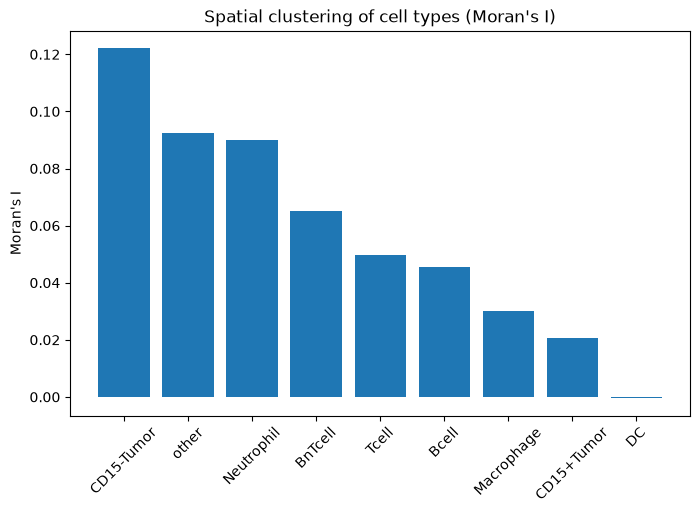

In [11]:
#for a more clear plot
moran_sorted = moran_df.sort_values(
    "morans_I",
    ascending=False
)
#plotting
plt.figure(figsize=(8,5))


plt.bar(
    moran_sorted["cell.type"],
    moran_sorted["morans_I"]
)


plt.xticks(rotation=45)
plt.ylabel("Moran's I")
plt.title("Spatial clustering of cell types (Moran's I)")

plt.savefig(
    "outputs/d2_spataial_clustering_cell_types.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Permutation null

In [12]:
#using 200
def permutation_test(x, neighbors, n_perm=200):
    #for real data
    observed = morans_I(x, neighbors)
    null = []

    for _ in range(n_perm):

        shuffled = np.random.permutation(x)

        #for shuffled
        null.append(morans_I(shuffled, neighbors))

    return observed, np.array(null)


#for all cell types
perm_results = []

for ct in CELL_TYPES:

    #indicator for this cell type
    x = (
        df["cell.type"] == ct
    ).astype(int).values


    #observed + 200 random shuffles
    obs, null = permutation_test(
        x,
        neighbors,
        200
    )
    #empirical p-value
    p = (np.sum(null >= obs)+1)/(len(null)+1)

    perm_results.append({
        "cell.type":ct,
        "morans_I":obs,
        "p_value":p,
        "null_low":np.percentile(null,2.5),
        "null_high":np.percentile(null,97.5)
    })

perm_df = pd.DataFrame(perm_results)

perm_df


,cell.type,morans_I,p_value,null_low,null_high
0,CD15-Tumor,0.122165,0.004975,-0.004253,0.003548
1,CD15+Tumor,0.020565,0.004975,-0.003887,0.003709
2,Tcell,0.049878,0.004975,-0.004274,0.003526
3,Bcell,0.045385,0.004975,-0.003004,0.003723
4,BnTcell,0.065049,0.004975,-0.004001,0.003977
5,Macrophage,0.030260,0.004975,-0.003747,0.003462
6,DC,-0.000436,0.741294,-0.000474,0.004470
7,Neutrophil,0.090163,0.004975,-0.002918,0.003785
8,other,0.092500,0.004975,-0.003642,0.003509


### Visualization

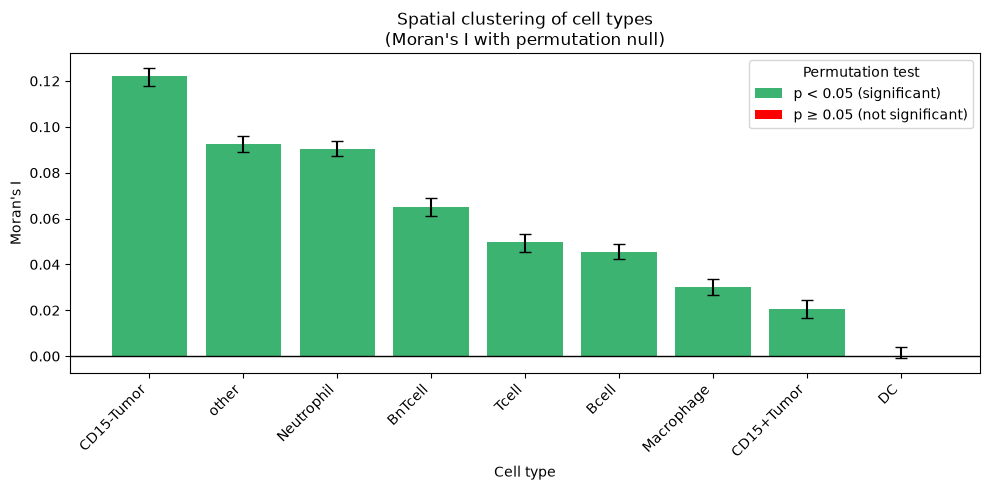

In [13]:
#plot: bar chart of I values with error bars from the null
plot_df = perm_df.sort_values(
    "morans_I",
    ascending=False
)


#null
yerr = np.vstack([
    plot_df["null_low"].abs(),
    plot_df["null_high"].abs()
])


#colors based on p-value
colors = [
    "mediumseagreen" if p < 0.05 else "red"
    for p in plot_df["p_value"]
]

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["cell.type"],
    plot_df["morans_I"],
    yerr=yerr,
    capsize=4,
    color=colors
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

legend_elements = [
    Patch(facecolor="mediumseagreen", label="p < 0.05 (significant)"),
    Patch(facecolor="red", label="p ≥ 0.05 (not significant)")
]

plt.legend(handles=legend_elements, title="Permutation test")
plt.xticks(rotation=45,ha="right")
plt.ylabel("Moran's I")
plt.xlabel("Cell type")
plt.title("Spatial clustering of cell types\n(Moran's I with permutation null)")
plt.tight_layout()
plt.savefig(
    "outputs/d2_spataial_clustering_cell_types_permutation_null.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

###  Cross-patient interpretation

In [14]:
#Moran for all patients (T cells)

moran_patients = []

for patient_file in SAMPLE_FILES:

    patient_id = Path(patient_file).name.split("-")[2]

    df_p = pd.read_csv(patient_file, sep="\t")

    #subsample
    df_p = df_p.sample(
        min(50000, len(df_p)),
        random_state=42
    ).reset_index(drop=True)


    coords = df_p[["nucleus.x","nucleus.y"]].values

    tree = cKDTree(coords)


    _, neighbors_p = tree.query(coords, k=11)
    neighbors_p = neighbors_p[:,1:]

    #T cell indicator
    x = (
        df_p["cell.type"] == "Tcell"
    ).astype(int).values

    I = morans_I(x, neighbors_p)

    moran_patients.append({
        "patient": patient_id,
        "Tcell_Moran": I
    })

moran_patients = pd.DataFrame(moran_patients)
moran_patients

,patient,Tcell_Moran
0,0558,0.049878
1,0565,0.086730
2,0587,0.200855
3,0591,0.084074
4,0593,0.077746
5,0612,0.110028
6,0613,0.319739
7,0616,0.060280
8,0657,0.077147
9,0659,0.106163


In [15]:
#connecting it to D1 infiltration
combined = ranked.merge(
    moran_patients,
    on="patient"
)

combined

,patient,roi_used,n_T_cells,infiltration_score,Tcell_Moran
0,0699,in.ROI.tumor_tissue,159587,54.873035,0.117293
1,0587,in.ROI.tumor_tissue,217089,43.126094,0.200855
2,0664,in.ROI.tumor_tissue,44801,37.813225,0.068960
3,0558,in.ROI.tumor_tissue,272987,37.051990,0.049878
4,0613,in.ROI.tumor_tissue,180041,30.793668,0.319739
5,0696,in.ROI.1,49044,30.346334,0.078231
6,0657,in.ROI.tumor_tissue,47603,29.689224,0.077147
7,0721,in.ROI.1,10901,27.804496,0.160342
8,0591,in.ROI.tumor_tissue,77447,27.668394,0.084074
9,0565,in.ROI.tumor_tissue,92434,27.136414,0.086730


### Visualization

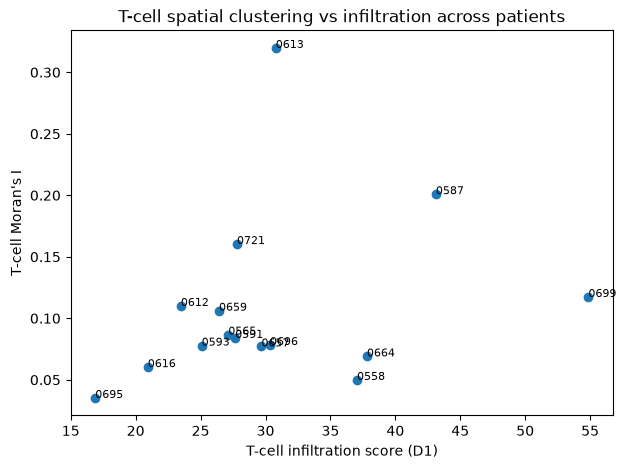

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(
    combined["infiltration_score"],
    combined["Tcell_Moran"]
)

for _, row in combined.iterrows():
    plt.text(
        row["infiltration_score"],
        row["Tcell_Moran"],
        row["patient"],
        fontsize=8
    )

plt.xlabel("T-cell infiltration score (D1)")
plt.ylabel("T-cell Moran's I")
plt.title("T-cell spatial clustering vs infiltration across patients")

plt.savefig(
    "outputs/d1_vs_d2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


T-cell clustering and infiltration were not always directly linked. Some patients showed both high infiltration and strong clustering (e.g. 0587), while others showed strong T-cell clustering with medium infiltration (e.g. 0613). This suggests that Moran’s I captures immune spatial organisation, whereas D1 infiltration score captures tumour penetration, which are different aspects of immune organisation.


## Part 3 -Patient Stratification from Spatial Features
### Firstly, niche analysis

In [17]:
all_dfs = []

for file in SAMPLE_FILES:

    patient_id = Path(file).name.split("-")[2]

    #load spatial cell-level data
    temp = pd.read_csv(
        file,
        sep="\t"
    )
    #add id
    temp["patient"] = patient_id

    all_dfs.append(temp)

#combine all patients into one dataframe
df_all = pd.concat(
    all_dfs,
    ignore_index=True
)

#subsample to reduce memory usage but keep information representative
df_niche = df_all.sample(
    5_000_000,
    random_state=42
).reset_index(drop=True)


print(df_niche.shape)
print(df_niche["patient"].nunique())

#knn
coords = df_niche[
    ["nucleus.x","nucleus.y"]
].values

tree = cKDTree(coords)

#find 10 nearest neighbours for each cell (11 because teh 1st is its own neighbour)
_, knn_indices = tree.query(
    coords,
    k=11
)

knn_indices = knn_indices[:,1:]

(5000000, 26)
15


In [18]:
CELL_TYPES = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC",
    "Neutrophil", "other"
]

#convert celltype names into numerical indices (for one hot)
ct_to_idx = {
    ct:i for i,ct in enumerate(CELL_TYPES)
}


#numerical representatin, unknown cell types are -1
ct_array = df_niche["cell.type"].map(
    ct_to_idx
).fillna(-1).astype(int).values


ct_safe = ct_array.copy()

ct_safe[ct_safe < 0] = N_TYPES

#one-hot encode cell types -> each cell a vector of 9
one_hot = np.eye(
    N_TYPES + 1,
    dtype=np.float32
)[ct_safe]

one_hot = one_hot[:,:N_TYPES]


#neighbourhood composition bags
bags = one_hot[knn_indices].mean(axis=1)

print(bags.shape)


#L1 normalisation to correct noise
X = normalize(bags,norm="l1")

K_NICHES = 6


km_final = MiniBatchKMeans(
    n_clusters=K_NICHES,
    random_state=42,
    n_init=10
)

#assign each cell to a niche
niche_labels = km_final.fit_predict(X)


df_niche["niche"] = niche_labels

df_niche[["cell.type","niche"]].head()

(5000000, 9)


,cell.type,niche
0,CD15-Tumor,1
1,CD15-Tumor,4
2,CD15-Tumor,1
3,CD15-Tumor,4
4,CD15+Tumor,2


### Niche fractions per patient

In [19]:
#fraction of each spatial niche for patient
niche_fraction = (
    df_niche
    .groupby(["patient","niche"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x/x.sum())
    .unstack(fill_value=0)
)


niche_fraction.columns = [
    f"niche_{c}_fraction"
    for c in niche_fraction.columns
]

#final matrix: row - patient, one feature per niche
niche_fraction = niche_fraction.reset_index()
niche_fraction

,patient,niche_0_fraction,niche_1_fraction,niche_2_fraction,niche_3_fraction,niche_4_fraction,niche_5_fraction
0,0558,0.160442,0.117000,0.132568,0.231926,0.184034,0.174030
1,0565,0.185021,0.099667,0.128985,0.239891,0.191377,0.155058
2,0587,0.189900,0.122004,0.122653,0.217435,0.205605,0.142404
3,0591,0.217763,0.093292,0.122344,0.229448,0.167183,0.169970
4,0593,0.178813,0.127267,0.127874,0.213684,0.192126,0.160237
5,0612,0.214140,0.094327,0.113090,0.237031,0.208443,0.132970
6,0613,0.157387,0.105972,0.199104,0.198529,0.159166,0.179841
7,0616,0.192297,0.108791,0.121072,0.230669,0.194582,0.152589
8,0657,0.181441,0.177430,0.117891,0.176301,0.216702,0.130235
9,0659,0.202476,0.113434,0.121382,0.224716,0.198281,0.139711


### Niche self-adjency

In [20]:
# calculate niche self-adjacency for each patient
# measures how often cells from the same niche have neighbours from the same niche

self_adj = []

#fir each patient
for patient, df_p in df_niche.groupby("patient"):

    coords = df_p[["nucleus.x","nucleus.y"]].values

    tree = cKDTree(coords)

    #find 10 nearest neighbours for each cell (again)
    _, neigh = tree.query(
        coords,
        k=11
    )

    #remove the self neighbour
    neigh = neigh[:,1:]

    #niche labels for the patient
    niches = df_p["niche"].values

    result = {"patient": patient}

    # self-adjacency for every niche
    for niche_id in range(K_NICHES):

        mask = niches == niche_id

        #if no niche in patient, assign zero
        if mask.sum() == 0:
            score = 0
        else:
            #check if neighbours of niche cells belong to the same niche
            same = (niches[neigh[mask]] == niche_id)
            #fraction of same niche neighbours
            score = same.mean()

        result[
            f"niche_{niche_id}_self_adj"] = score

    self_adj.append(result)

self_adj = pd.DataFrame(self_adj)

self_adj.head()

,patient,niche_0_self_adj,niche_1_self_adj,niche_2_self_adj,niche_3_self_adj,niche_4_self_adj,niche_5_self_adj
0,0558,0.309515,0.280208,0.259049,0.290266,0.246993,0.281350
1,0565,0.333359,0.214819,0.234846,0.289373,0.247436,0.243493
2,0587,0.351016,0.290858,0.251272,0.274111,0.272516,0.235242
3,0591,0.453739,0.239260,0.261421,0.306477,0.246128,0.337289
4,0593,0.362682,0.320881,0.284998,0.284235,0.270632,0.278614


### Feature matrix

In [21]:
features = (
    niche_fraction
    .merge(
        self_adj,
        on="patient"
    )
    .merge(
        ranked[["patient","infiltration_score"]],
        on="patient"
    )
    .merge(
        moran_patients,
        on="patient"
    )
)


features.head()

,patient,niche_0_fraction,niche_1_fraction,niche_2_fraction,niche_3_fraction,niche_4_fraction,niche_5_fraction,niche_0_self_adj,niche_1_self_adj,niche_2_self_adj,niche_3_self_adj,niche_4_self_adj,niche_5_self_adj,infiltration_score,Tcell_Moran
0,0558,0.160442,0.117000,0.132568,0.231926,0.184034,0.174030,0.309515,0.280208,0.259049,0.290266,0.246993,0.281350,37.051990,0.049878
1,0565,0.185021,0.099667,0.128985,0.239891,0.191377,0.155058,0.333359,0.214819,0.234846,0.289373,0.247436,0.243493,27.136414,0.086730
2,0587,0.189900,0.122004,0.122653,0.217435,0.205605,0.142404,0.351016,0.290858,0.251272,0.274111,0.272516,0.235242,43.126094,0.200855
3,0591,0.217763,0.093292,0.122344,0.229448,0.167183,0.169970,0.453739,0.239260,0.261421,0.306477,0.246128,0.337289,27.668394,0.084074
4,0593,0.178813,0.127267,0.127874,0.213684,0.192126,0.160237,0.362682,0.320881,0.284998,0.284235,0.270632,0.278614,25.083859,0.077746


### PCA with 2 components

In [22]:
X = features.drop(
    columns=[
        "patient",
        
    ]
)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)

PC = pca.fit_transform(X_scaled)
features["PC1"] = PC[:,0]
features["PC2"] = PC[:,1]

### Visualization

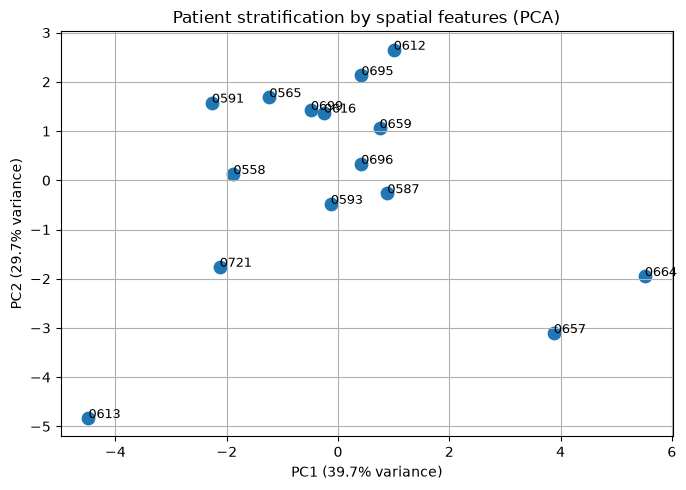

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(
    features["PC1"],
    features["PC2"],
    s=80
)

for _, row in features.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        row["patient"],
        fontsize=9
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Patient stratification by spatial features (PCA)")

plt.grid()
plt.tight_layout()
plt.savefig(
    "outputs/d3_pca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
print("PC1 explained variance:", pca.explained_variance_ratio_[0])
print("PC2 explained variance:", pca.explained_variance_ratio_[1])
print("PC1 + PC2 total:", pca.explained_variance_ratio_[:2].sum())

PC1 explained variance: 0.39657471063430966
PC2 explained variance: 0.29654515421692745
PC1 + PC2 total: 0.6931198648512371


In [25]:
#less dimensions
PC = pca.fit_transform(X_scaled)

#store the coordinates
features["PC1"] = PC[:,0]
features["PC2"] = PC[:,1]
features["PC3"] = PC[:,2]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)
#patient clustering in PCA space
features["cluster"] = kmeans.fit_predict(PC)


#summary
cluster_summary = (
    features
    .groupby("cluster")
    .mean(numeric_only=True)
)


print("========cluster summary=========")
cluster_summary[["Tcell_Moran", "infiltration_score"]]



========cluster summary=========


,Tcell_Moran,infiltration_score
cluster,,
0,0.073054,33.751224
1,0.240041,29.299082
2,0.091499,30.273416


In [28]:
#assigning labels

labels = {
    0: "infiltration-dominant",
    1: "spatially-organised immune",
    2: "mixed"
}

features["biological_label"] = (
    features["cluster"]
    .map(labels)
)


features["biological_label"] = (
    features["cluster"]
    .map(labels)
)

print("========patient features=========")
features[
    ["patient",
     "cluster",
     "biological_label"]
].sort_values("cluster")

========patient features=========


,patient,cluster,biological_label
10,0664,0,infiltration-dominant
8,0657,0,infiltration-dominant
6,0613,1,spatially-organised immune
14,0721,1,spatially-organised immune
3,0591,2,mixed
0,0558,2,mixed
2,0587,2,mixed
1,0565,2,mixed
7,0616,2,mixed
5,0612,2,mixed



## Visualization

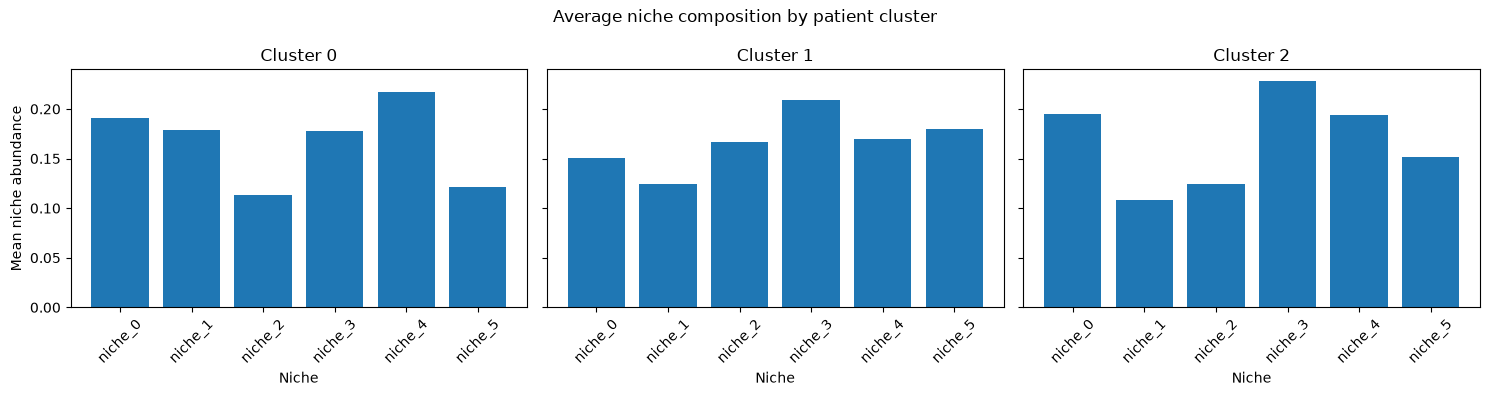

In [29]:
niche_cols = [
    c for c in features.columns
    if "niche_" in c and "fraction" in c
]
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, cluster_id in zip(axes, sorted(features["cluster"].unique())):

    cluster_mean = (
        features[
            features["cluster"] == cluster_id
        ][niche_cols]
        .mean()
    )
    #better labels
    labels = [x.replace("_fraction","") for x in cluster_mean.index]

    ax.bar(labels, cluster_mean.values)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Niche")
    ax.tick_params(axis="x",rotation=45)

axes[0].set_ylabel("Mean niche abundance")

plt.suptitle("Average niche composition by patient cluster")
plt.savefig(
    "outputs/d3_clusters_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

Patient differences were mainly driven by T-cell infiltration, T-cell Moran’s I, and niche composition. Cluster 0 (n=2) showed the highest T-cell infiltration with lower spatial clustering, suggesting an infiltration-dominant/inflamed phenotype. Cluster 1 (n=2) had the highest Moran’s I with lower infiltration, indicating a spatially organised immune phenotype with strong local T-cell clustering rather than widespread infiltration. Cluster 2 (n=10) showed intermediate values for both features and was classified as mixed. Niche fractions also differed between groups, suggesting variation in local tissue organisation, although T-cell spatial features showed the strongest separation. No cluster showed a clear immune-excluded phenotype based on these spatial features alone.